<a href="https://colab.research.google.com/github/torcodex/Python-Practices/blob/main/US_Honey_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('/content/drive/MyDrive/US_honey_dataset (1).csv')
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [16]:
df.shape

(1115, 9)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [18]:
df.drop(columns={'Unnamed: 0'}, inplace=True)

In [23]:
df['colonies_number'].duplicated().sum()

np.int64(926)

# Insights:


1.   0 null values
2.   0 duplicated values
3.   1 unnecessary column
3.   1 miscalculated column. we fixed it:-
        * Upto 2009 --> Data was correct for production (honey production = yield_per_colony * Production)
        * After 2009 --> Data is getting incorrect



In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
colonies_number,1115.0,6.243857e+04,9.264818e+04,2000.0,9000.0,26000.0,69000.0,550000.0
yield_per_colony,1115.0,5.974350e+01,1.994050e+01,19.0,45.0,57.0,71.0,155.0
production,1115.0,2.851268e+06,5.561202e+06,12000.0,246000.0,828000.0,2700000.0,39060000.0
stocks,1115.0,1.172625e+06,2.049556e+06,9000.0,112500.0,370000.0,1253500.0,13545000.0
average_price,1115.0,1.406231e+02,1.070115e+02,1.3,70.0,128.0,193.0,874.0
value_of_production,1115.0,5.667412e+06,9.459460e+06,106000.0,1008000.0,2281000.0,5704000.0,83859000.0
year,1115.0,2.007741e+03,7.823002e+00,1995.0,2001.0,2008.0,2015.0,2021.0


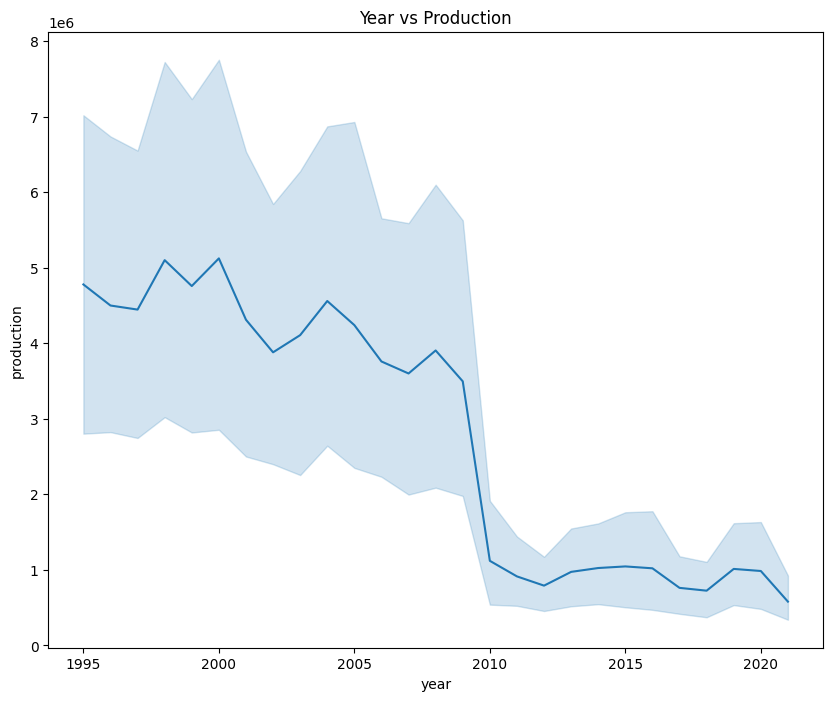

In [50]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df, x='year', y='production')
plt.title('Year vs Production')
plt.show()

In [48]:
df['actual_Production'] = df['colonies_number'] * df['yield_per_colony']
df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year,actual_value_of_Production,actual_Production
0,Alabama,16000,58,928000,28000,62.00,575000,1995,928000,928000
1,Arizona,52000,79,4108000,986000,68.00,2793000,1995,4108000,4108000
2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995,3000000,3000000
3,California,420000,93,39060000,4687000,60.00,23436000,1995,39060000,39060000
4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995,2700000,2700000
...,...,...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021,240000,240000
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021,3072000,3072000
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021,258000,258000
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021,1974000,1974000


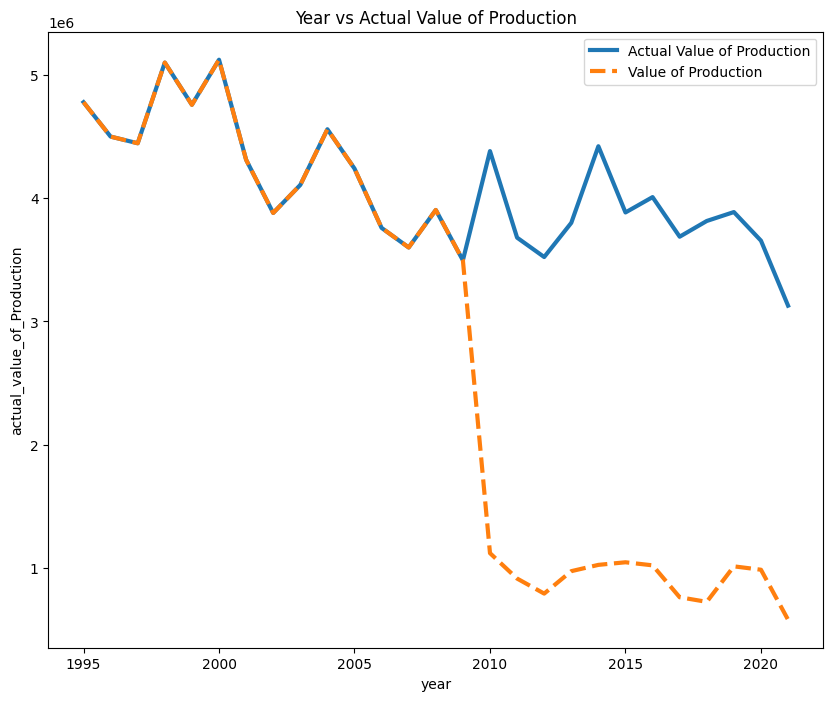

In [47]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df, x='year', y='actual_value_of_Production', linewidth=3, errorbar=None, label='Actual Value of Production')
sns.lineplot(data=df, x='year', y='production', linestyle='--', linewidth=3, errorbar=None, label='Value of Production')
plt.title('Year vs Actual Value of Production')
plt.legend()
plt.show()

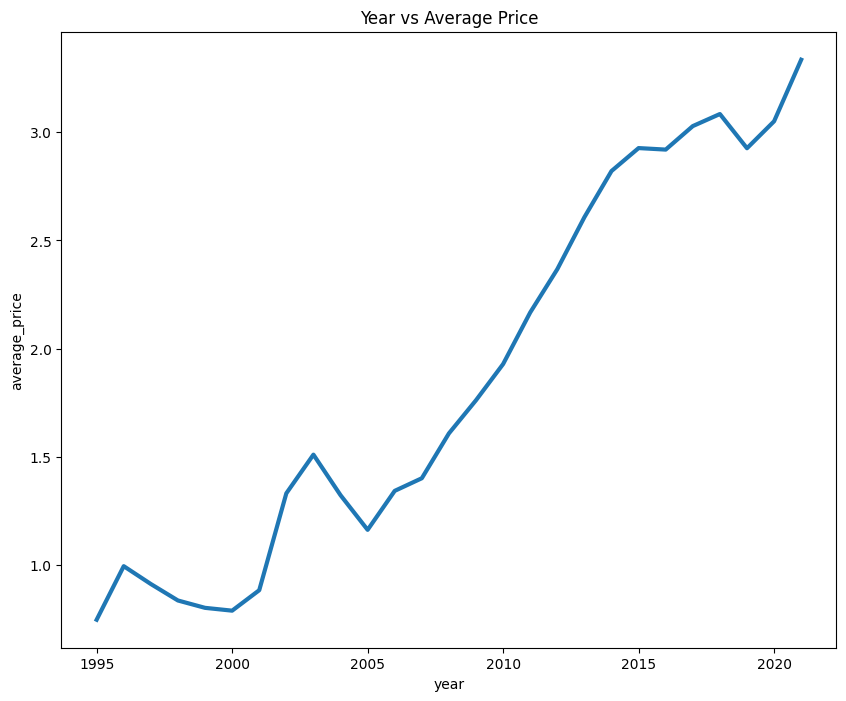

In [60]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df, x='year', y='average_price', linewidth=3, errorbar=None)
plt.title('Year vs Average Price')
plt.show()

In [55]:
df[df['year']>2017]

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year,actual_value_of_Production,actual_Production
955,Alabama,6000,45,14000,14000,3.72,1004000,2018,270000,270000
956,Arizona,24000,38,109000,109000,3.01,2745000,2018,912000,912000
957,Arkansas,28000,50,84000,84000,1.88,2632000,2018,1400000,1400000
958,California,335000,41,3022000,3022000,2.11,28981000,2018,13735000,13735000
959,Colorado,31000,48,283000,283000,2.05,3050000,2018,1488000,1488000
...,...,...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021,240000,240000
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021,3072000,3072000
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021,258000,258000
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021,1974000,1974000


In [58]:
df.loc[df['year']<=2017, 'average_price'] = df['average_price']/100

In [64]:
df.drop(columns={'production'},inplace=True)
df

,state,colonies_number,yield_per_colony,stocks,average_price,value_of_production,year,actual_Production
0,Alabama,16000,58,28000,0.62,575000,1995,928000
1,Arizona,52000,79,986000,0.68,2793000,1995,4108000
2,Arkansas,50000,60,900000,0.64,1920000,1995,3000000
3,California,420000,93,4687000,0.60,23436000,1995,39060000
4,Colorado,45000,60,1404000,0.68,1836000,1995,2700000
...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,8.23,1975000,2021,240000
1111,Washington,96000,32,1206000,2.52,7741000,2021,3072000
1112,WestVirginia,6000,43,136000,4.80,1238000,2021,258000
1113,Wisconsin,42000,47,750000,2.81,5547000,2021,1974000


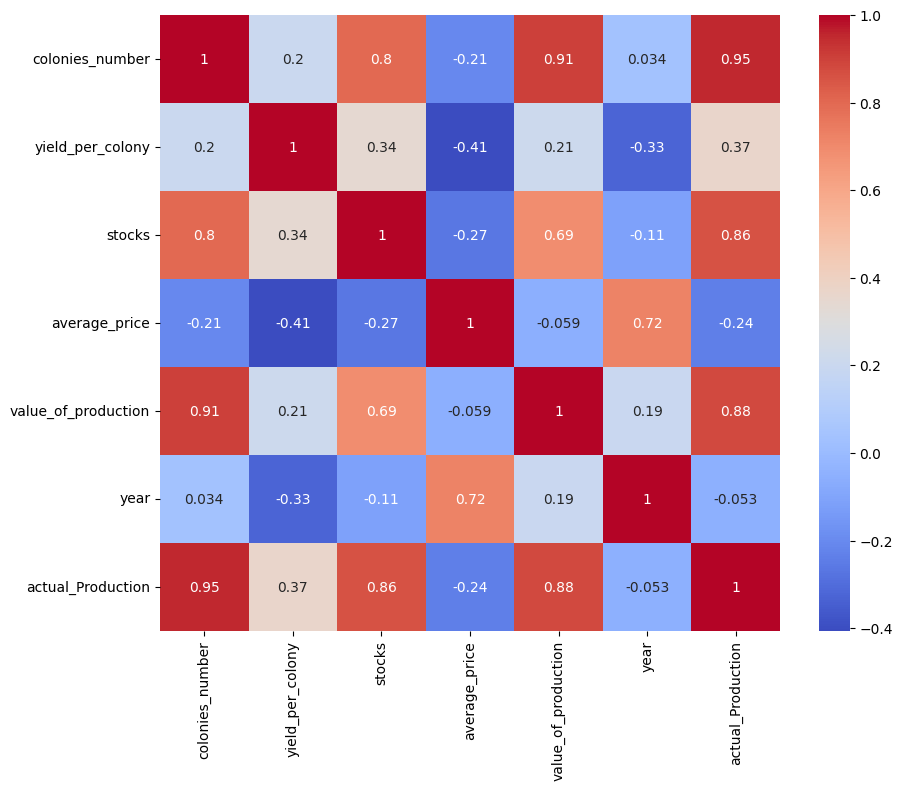

In [65]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [69]:
top10 = df.groupby('state')['actual_Production'].sum().sort_values(ascending=False).head(10)

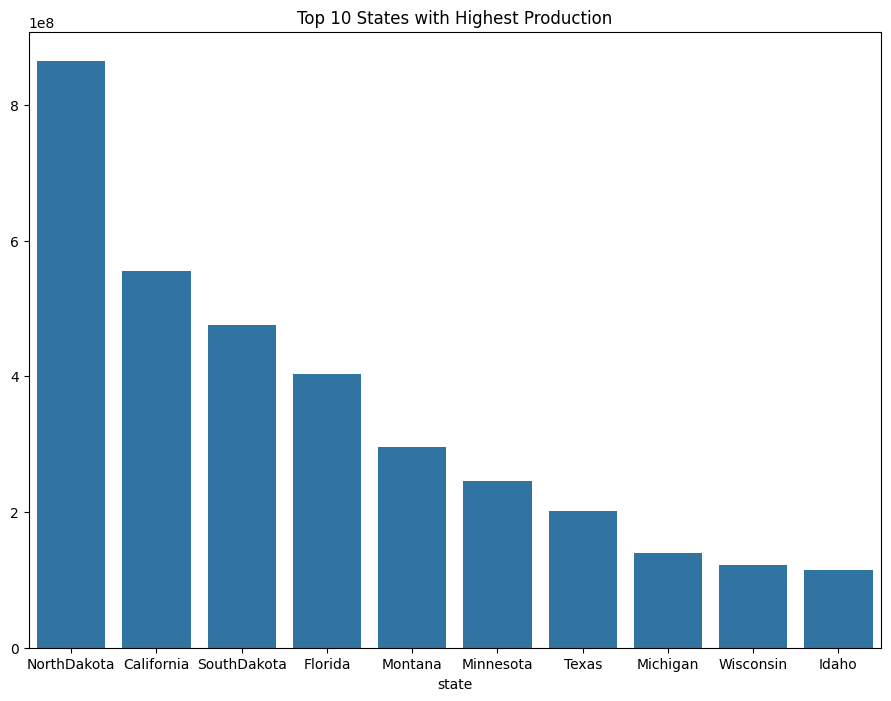

In [73]:
plt.figure(figsize=(11,8))
sns.barplot(x=top10.index, y=top10.values)
plt.title('Top 10 States with Highest Production')
plt.show()